Bohua Liu is responsible for this code

### Tiling Image

In [ ]:
# Slicing Script (Updated for Train AND Val)
import os
import cv2
import numpy as np
from shapely.geometry import Polygon, box
from tqdm import tqdm
import shutil

# CONFIGURATION
# ROOT INPUT: The folder containing 'train' and 'val' folders
INPUT_ROOT = "dataset_yolo_4cats_seg" 

# ROOT OUTPUT: Where the new tiled dataset will be created
OUTPUT_ROOT = "dataset_yolo_tiled"

TILE_SIZE = 640
OVERLAP = 0.2
MIN_VISIBILITY = 0.3

def slice_subset(subset_name):
    """
    Slices a specific subset (e.g., 'train' or 'val')
    """
    input_img_dir = os.path.join(INPUT_ROOT, "images", subset_name)
    input_lbl_dir = os.path.join(INPUT_ROOT, "labels", subset_name)
    
    output_img_dir = os.path.join(OUTPUT_ROOT, "images", subset_name)
    output_lbl_dir = os.path.join(OUTPUT_ROOT, "labels", subset_name)

    # Create directories
    os.makedirs(output_img_dir, exist_ok=True)
    os.makedirs(output_lbl_dir, exist_ok=True)

    # Check if input directory exists
    if not os.path.exists(input_img_dir):
        print(f"Warning: {input_img_dir} not found. Skipping.")
        return

    img_files = [f for f in os.listdir(input_img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    print(f"--- Processing '{subset_name}' set ({len(img_files)} images) ---")

    tile_count = 0

    for img_name in tqdm(img_files):
        img_path = os.path.join(input_img_dir, img_name)
        lbl_path = os.path.join(input_lbl_dir, os.path.splitext(img_name)[0] + ".txt")
        
        img = cv2.imread(img_path)
        if img is None: continue
        h_img, w_img, _ = img.shape

        # 1. Load Polygons
        polygons = []
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = list(map(float, line.strip().split()))
                    cls = int(parts[0])
                    coords = parts[1:]
                    pts = [(coords[i]*w_img, coords[i+1]*h_img) for i in range(0, len(coords), 2)]
                    if len(pts) >= 3:
                        poly = Polygon(pts)
                        if poly.is_valid:
                            polygons.append({'cls': cls, 'poly': poly})

        # 2. Grid Calculation
        step = int(TILE_SIZE * (1 - OVERLAP))
        
        # 3. Slicing Loop
        for y in range(0, h_img, step):
            for x in range(0, w_img, step):
                x_start = min(x, w_img - TILE_SIZE)
                y_start = min(y, h_img - TILE_SIZE)
                if x_start < 0: x_start = 0
                if y_start < 0: y_start = 0
                x_end, y_end = x_start + TILE_SIZE, y_start + TILE_SIZE

                tile_box = box(x_start, y_start, x_end, y_end)
                new_labels = []

                # 4. Check Intersections
                for obj in polygons:
                    if tile_box.intersects(obj['poly']):
                        inter = tile_box.intersection(obj['poly'])
                        if inter.area / obj['poly'].area > MIN_VISIBILITY:
                            if inter.geom_type == 'Polygon':
                                coords = list(inter.exterior.coords)
                            elif inter.geom_type == 'MultiPolygon':
                                coords = list(max(inter.geoms, key=lambda a: a.area).exterior.coords)
                            else: continue
                            
                            norm_coords = []
                            for pt in coords:
                                nx = max(0, min(1, (pt[0] - x_start) / TILE_SIZE))
                                ny = max(0, min(1, (pt[1] - y_start) / TILE_SIZE))
                                norm_coords.extend([nx, ny])
                            
                            new_labels.append(f"{obj['cls']} {' '.join(map(str, norm_coords))}")

                # 5. Save only non-empty tiles
                if len(new_labels) > 0:
                    tile_name = f"{os.path.splitext(img_name)[0]}_{x_start}_{y_start}"
                    cv2.imwrite(os.path.join(output_img_dir, tile_name + ".jpg"), img[y_start:y_end, x_start:x_end])
                    with open(os.path.join(output_lbl_dir, tile_name + ".txt"), 'w') as f:
                        f.write('\n'.join(new_labels))
                    tile_count += 1

    print(f"Finished '{subset_name}'. Generated {tile_count} dense tiles.")

# EXECUTION
if os.path.exists(OUTPUT_ROOT): shutil.rmtree(OUTPUT_ROOT) # Clean start
slice_subset("train")
slice_subset("val") 
print(f"All done! Dataset saved to {OUTPUT_ROOT}")

import os
from ultralytics import YOLO

# Create the config file pointing to the NEW sliced folders
tiled_yaml_content = f"""
path: {os.path.abspath("dataset_yolo_tiled")}
train: images/train
val: images/val    
names:
  0: plastic
  1: glass
  2: paper
  3: unsorted
"""

with open("dataset_yolo_tiled/taco_tiled.yaml", "w") as f:
    f.write(tiled_yaml_content)


--- Processing 'train' set (1275 images) ---


  0%|          | 0/1275 [00:00<?, ?it/s]

100%|██████████| 1275/1275 [01:19<00:00, 15.96it/s]


Finished 'train'. Generated 5851 dense tiles.
--- Processing 'val' set (225 images) ---


100%|██████████| 225/225 [00:14<00:00, 15.26it/s]

Finished 'val'. Generated 1026 dense tiles.
All done! Dataset saved to dataset_taco_tiled


### Oversampling

In [ ]:
from pathlib import Path
from collections import defaultdict

# Settings
img_dir = Path("dataset_yolo_tiled/images/train")
labels_dir = Path("dataset_yolo_tiled/labels/train")
output_txt = img_dir.parent / "train_oversampled1.txt"

names = ["plastic", "glass", "paper", "unsorted"]
class_weights = {
    "plastic": 1,
    "glass": 5,
    "paper": 3,
    "unsorted": 1
}
idx_to_class = {i: name for i, name in enumerate(names)}

# Build image list
image_paths = sorted(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))
oversampled_lines = []

for img_path in image_paths:
    label_path = labels_dir / (img_path.stem + ".txt")
    if not label_path.exists():
        continue

    with open(label_path, "r") as f:
        lines = f.read().splitlines()
    class_ids = {int(l.split()[0]) for l in lines if l.strip()}

    if not class_ids:
        repeat_factor = 1
    else:
        classes = [idx_to_class[c] for c in class_ids]
        repeat_factor = max(class_weights.get(c, 1) for c in classes)

    oversampled_lines.extend([str(img_path.resolve())] * repeat_factor)

# Write to file
with open(output_txt, "w") as f:
    f.write("\n".join(oversampled_lines))

print(f"Oversampled train list saved to: {output_txt}")


In [ ]:
import os
from ultralytics import YOLO

model = YOLO('yolov8s.pt') 

# TRAIN WITH "HARD MODE" SETTINGS
model.train(
    data="dataset_yolo_tiled/taco_oversampled.yaml",
    epochs=500,
    batch=32,
    imgsz=640,       
    name="yolov8s_tiled_BEST_CONFIG",
    project="Yolo_training",
    seed=42,
    
    # HARD AUGMENTATION
    # These make the training hard, ensuring high generalization
    degrees=15.0,    
    flipud=0.5,    
    fliplr=0.5,      
    scale=0.6,       
    
    mosaic=1.0,      # Always use Mosaic (4 images in 1)
    mixup=0.2,      
    copy_paste=0.3,  # Occlusion (Hard for detection)
    erasing=0.4,     # Randomly hide parts of the trash
    
    # COLOR VARIATION
    hsv_h=0.015,     
    hsv_s=0.5,       
    hsv_v=0.4,       
    
    # OPTIMIZATION
    lr0=0.01,        # Standard starting LR
    lrf=0.01,        # Final LR (divides lr0 by 100)
    patience=50,     # Give it time to struggle and recover
    close_mosaic=20, # Turn off the "hard" mosaic effects for the last 20 epochs

    cls=3,         # Focus on classification (Important for 4 similar classes)
    box=10,        # Tight boxes (Harder)

    # REGULARIZATION
    # This prevents the model from memorizing the tiles
    weight_decay=0.0005, 
    label_smoothing=0.1, 
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.233 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 15948MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=10, cache=False, cfg=None, classes=None, close_mosaic=20, cls=3, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo_tiled/taco_oversampled.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_tiled_BEST_CONFIG2, nbs=64, nms=False, op

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
from ultralytics import YOLO

# Path to your dataset
yaml_directory = "dataset_yolo_tiled/taco_oversampled.yaml"
model = YOLO("Yolo_training/yolov8s_tiled_BEST_CONFIG2/weights/best.pt")
metrics = model.val(data=yaml_directory,name="yolov8s_tiled_BEST_CONFIG2",project="Yolo_validation")
print(metrics)

Ultralytics 8.3.233 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 15948MiB)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3553.7±976.5 MB/s, size: 97.8 KB)
val: Scanning /home/default/Desktop/project/Dataset 4cats/dataset_yolo_tiled/labels/val.cache... 989 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 989/989 1.5Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 2.9it/s 21.0s0.3ss


/home/default/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


                   all        989       1375      0.436      0.415      0.378       0.29
               plastic        525        627      0.533      0.594      0.553      0.431
                 glass         45         53      0.308      0.264      0.217       0.16
                 paper        121        130      0.399      0.369      0.308      0.271
              unsorted        405        565      0.505      0.432      0.433      0.299
Speed: 0.6ms preprocess, 18.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /home/default/Desktop/project/Dataset 4cats/Yolo_validation/yolov8m_tiled_v2_balanced
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b3562ab8ca0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0

Print val and train cls loss

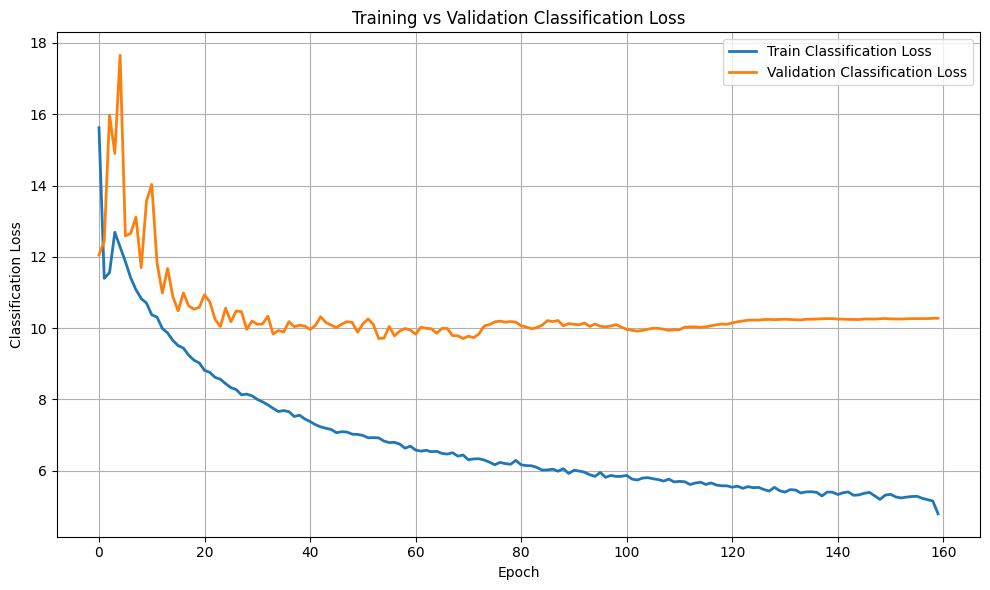

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV (update the path if needed)
df = pd.read_csv("v4_outputs/results.csv")

# YOLO naming convention: keys vary slightly by version
# Try common column names:
train_key = "train/cls_loss" if "train/cls_loss" in df.columns else "cls_loss"
val_key = "val/cls_loss" if "val/cls_loss" in df.columns else "cls_loss_val"

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df[train_key], label="Train Classification Loss", linewidth=2)
plt.plot(df[val_key], label="Validation Classification Loss", linewidth=2)

plt.title("Training vs Validation Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Classification Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
